# A Hybrid and Explainable Architecture for Early Sepsis Phenotyping and Prediction

## François Zapletal

This notebook implements a full pipeline completly reproductible for sepsis early prediction using MIMIC-III data.

1. **Device setup** : detect available hardware (DirectML / CUDA / CPU)
2. **Encoding pipeline** : SAITS imputation, TS2Vec embedding, Autoencoder compression
3. **Data loading** : load pre-computed encoded representations
4. **Patient alignment** : align past and future sepsis windows per patient
5. **Phenotype clustering** : KMeans (k=4) on the future window embeddings
6. **Gating network** : train AttentionGatingNetwork to predict future clusters from past
7. **Mixture of Experts**:  grid search over MLP architectures, final model evaluation

Source modules: src/processor.py, src/embedder.py, src/gating_network.py, src/moe.py

Data is expected at data/Dataset.csv. Pre-computed representations are saved to data/sepsis_processed_full.npz.
Trained models are saved under models/.

In [1]:
# The libraires that you have to download

In [2]:
# pip install torch torchvision torchaudio torch-directml
# pip install pypots
# pip install scikit-learn pandas numpy matplotlib seaborn scipy

In [3]:
import sys
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

import torch
import torch_directml

from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from scipy.special import softmax

from embedder import SepsisEncodingPipeline
from gating_network import AttentionGatingNetwork
from moe import AttentionSepsisMoE, SepsisMoEDiagnostic

C:\Users\zaple\PycharmProjects\Research_Project_Sepsis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



████████╗██╗███╗   ███╗███████╗    ███████╗███████╗██████╗ ██╗███████╗███████╗    █████╗ ██╗
╚══██╔══╝██║████╗ ████║██╔════╝    ██╔════╝██╔════╝██╔══██╗██║██╔════╝██╔════╝   ██╔══██╗██║
   ██║   ██║██╔████╔██║█████╗█████╗███████╗█████╗  ██████╔╝██║█████╗  ███████╗   ███████║██║
   ██║   ██║██║╚██╔╝██║██╔══╝╚════╝╚════██║██╔══╝  ██╔══██╗██║██╔══╝  ╚════██║   ██╔══██║██║
   ██║   ██║██║ ╚═╝ ██║███████╗    ███████║███████╗██║  ██║██║███████╗███████║██╗██║  ██║██║
   ╚═╝   ╚═╝╚═╝     ╚═╝╚══════╝    ╚══════╝╚══════╝╚═╝  ╚═╝╚═╝╚══════╝╚══════╝╚═╝╚═╝  ╚═╝╚═╝
ai4ts v0.0.3 - building AI for unified time-series analysis, https://time-series.ai 



## 1. Device Setup

Detect available hardware for PyTorch acceleration.

In [4]:
if torch_directml.is_available():
    device_dml = torch_directml.device()
    print(f"GPU detected: {torch_directml.device_name(0)}")
else:
    device_dml = torch.device("cpu")
    print("DirectML not available, falling back to CPU.")

GPU detected: AMD Radeon RX 6600M 


## 2. Encoding Pipeline

Run the full SAITS + TS2Vec + Autoencoder pipeline.
Two pipelines are run:
- **Base pipeline** : pre-sepsis window [-17, -6], used for prediction
- **Centered pipeline** : peri-sepsis window [-6, +5], used for phenotyping

To reuse pre-trained models, pass them as arguments to pipeline.run(saits_model=..., ...).
Skip to the next section if encoded data is already saved.

Step 1: Data preparation and train/test split
Loading data from ../data/Dataset.csv...
Sepsis patients retained (window [-17, -6] inclusive): 1757
Non-sepsis patients retained (ratio 1.0): 1757
Non-physiological variables removed: 9 columns dropped.


2026-04-06 22:39:55 [INFO]: Using the given device: privateuseone:0
2026-04-06 22:39:55 [INFO]: Model files will be saved to models/saits_tmp\20260406_T223955
2026-04-06 22:39:55 [INFO]: Tensorboard file will be saved to models/saits_tmp\20260406_T223955\tensorboard
2026-04-06 22:39:55 [INFO]: Using customized MAE as the training loss function.
2026-04-06 22:39:55 [INFO]: Using customized MSE as the validation metric function.


Variables retained (50.0% presence threshold): 23 out of 37
<class 'pandas.DataFrame'>
RangeIndex: 42168 entries, 0 to 42167
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Hgb               3642 non-null   float64
 1   Hct               4400 non-null   float64
 2   Hour              42168 non-null  int64  
 3   Potassium         4840 non-null   float64
 4   Patient_ID        42168 non-null  int64  
 5   SBP               36133 non-null  float64
 6   BUN               3495 non-null   float64
 7   Glucose           8017 non-null   float64
 8   Resp              35745 non-null  float64
 9   DBP               29822 non-null  float64
 10  Temp              14974 non-null  float64
 11  WBC               3192 non-null   float64
 12  Creatinine        3017 non-null   float64
 13  Phosphate         2153 non-null   float64
 14  MAP               37497 non-null  float64
 15  Platelets         2931 non-null   floa

2026-04-06 22:39:55 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 413,024
C:\Users\zaple\PycharmProjects\Research_Project_Sepsis\.venv\Lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)
2026-04-06 22:40:02 [INFO]: Epoch 001 - training loss (MAE): 1.0358
2026-04-06 22:40:08 [INFO]: Epoch 002 - training loss (MAE): 0.7479
2026-04-06 22:40:15 [INFO]: Epoch 003 - training loss (MAE): 0.6852
2026-04-06 22:40:22 [INFO]: Epoch 004 - training loss (MAE): 0.6510
2026-04-06 22:40:28 [INFO]: Epoch 005 - training loss (MAE): 0.6246
2026-04-06 22:40:34 [INFO]: Epoch 006 - training loss (MAE): 0.6089
2026-04-06 22:40:

Step 3: TS2Vec embedding
Training TS2Vec...


2026-04-06 22:41:11 [INFO]: Epoch 001 - training loss (default): 2.4094
2026-04-06 22:41:16 [INFO]: Epoch 002 - training loss (default): 2.2188
2026-04-06 22:41:21 [INFO]: Epoch 003 - training loss (default): 1.9813
2026-04-06 22:41:26 [INFO]: Epoch 004 - training loss (default): 1.7691
2026-04-06 22:41:31 [INFO]: Epoch 005 - training loss (default): 1.6608
2026-04-06 22:41:36 [INFO]: Epoch 006 - training loss (default): 1.5331
2026-04-06 22:41:41 [INFO]: Epoch 007 - training loss (default): 1.4927
2026-04-06 22:41:46 [INFO]: Epoch 008 - training loss (default): 1.4575
2026-04-06 22:41:51 [INFO]: Epoch 009 - training loss (default): 1.4122
2026-04-06 22:41:56 [INFO]: Epoch 010 - training loss (default): 1.3628
2026-04-06 22:42:02 [INFO]: Epoch 011 - training loss (default): 1.3919
2026-04-06 22:42:07 [INFO]: Epoch 012 - training loss (default): 1.3889
2026-04-06 22:42:12 [INFO]: Epoch 013 - training loss (default): 1.3375
2026-04-06 22:42:17 [INFO]: Epoch 014 - training loss (default):

Step 4: Autoencoder
Training Autoencoder...
Epoch 05 | Train: 0.2389 | Val: 0.2202
Epoch 10 | Train: 0.1804 | Val: 0.1709
Epoch 15 | Train: 0.1593 | Val: 0.1495
Epoch 20 | Train: 0.1493 | Val: 0.1419
Epoch 25 | Train: 0.1421 | Val: 0.1331
Epoch 30 | Train: 0.1354 | Val: 0.1288
Epoch 35 | Train: 0.1287 | Val: 0.1243
Epoch 40 | Train: 0.1250 | Val: 0.1211
Epoch 45 | Train: 0.1231 | Val: 0.1196
Epoch 50 | Train: 0.1235 | Val: 0.1176


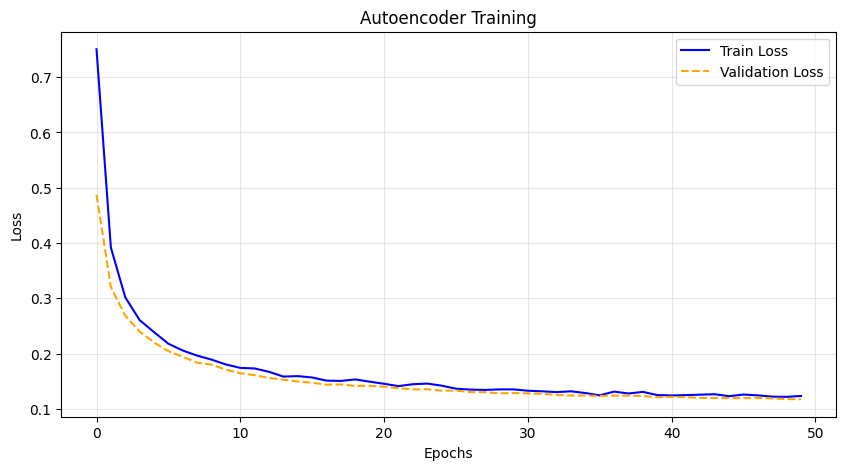

Pipeline complete. Train shape: (2811, 32), Test shape: (703, 32)
Saving models...
Error saving ../models/saits_model_base.pth: cannot pickle '_thread.lock' object
Error saving ../models/ts2vec_model_base.pth: cannot pickle '_thread.lock' object
Model saved: ../models/autoencoder_model_base.pth


In [5]:
pipeline = SepsisEncodingPipeline(
    file_path='../data/Dataset.csv',
    window_start=-17,
    window_end=-6,
    min_presence_pct=0.5,
    validation_split=0.2,
    essential_cols=None,
    saits_epochs=10,
    saits_batch_size=32,
    ts2vec_output_dims=32,
    ts2vec_epochs=30,
    ts2vec_batch_size=32,
    ae_latent_dim=32,
    ae_epochs=50,
    ae_batch_size=64,
    ae_lr=1e-3,
    device=device_dml,
    random_state=42
)
data_out, models_out = pipeline.run()

saits_trained, ts2vec_trained, ae_trained = models_out

print("Saving models...")
SepsisEncodingPipeline.save_model(saits_trained, "../models/saits_model_base.pth")
SepsisEncodingPipeline.save_model(ts2vec_trained, "../models/ts2vec_model_base.pth")
SepsisEncodingPipeline.save_model(ae_trained, "../models/autoencoder_model_base.pth")

Step 1: Data preparation and train/test split
Loading data from ../data/Dataset.csv...
Sepsis patients retained (window [-6, 5] inclusive): 2189
Non-sepsis patients retained (ratio 1.0): 2189
Non-physiological variables removed: 9 columns dropped.


2026-04-06 22:44:40 [INFO]: Using the given device: privateuseone:0
2026-04-06 22:44:40 [INFO]: Model files will be saved to models/saits_tmp\20260406_T224440
2026-04-06 22:44:40 [INFO]: Tensorboard file will be saved to models/saits_tmp\20260406_T224440\tensorboard
2026-04-06 22:44:40 [INFO]: Using customized MAE as the training loss function.
2026-04-06 22:44:40 [INFO]: Using customized MSE as the validation metric function.
2026-04-06 22:44:40 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 413,024


Variables retained (100.0% presence threshold): 23 out of 37
<class 'pandas.DataFrame'>
RangeIndex: 52536 entries, 0 to 52535
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Hgb               4513 non-null   float64
 1   Hct               5435 non-null   float64
 2   Hour              52536 non-null  int64  
 3   Potassium         5934 non-null   float64
 4   Patient_ID        52536 non-null  int64  
 5   BUN               4192 non-null   float64
 6   SBP               44509 non-null  float64
 7   Glucose           9589 non-null   float64
 8   Resp              44101 non-null  float64
 9   WBC               3890 non-null   float64
 10  Temp              18397 non-null  float64
 11  DBP               36188 non-null  float64
 12  Creatinine        3686 non-null   float64
 13  Phosphate         2524 non-null   float64
 14  Platelets         3624 non-null   float64
 15  MAP               46212 non-null  flo

2026-04-06 22:44:48 [INFO]: Epoch 001 - training loss (MAE): 0.9688
2026-04-06 22:44:56 [INFO]: Epoch 002 - training loss (MAE): 0.7257
2026-04-06 22:45:04 [INFO]: Epoch 003 - training loss (MAE): 0.6677
2026-04-06 22:45:12 [INFO]: Epoch 004 - training loss (MAE): 0.6362
2026-04-06 22:45:19 [INFO]: Epoch 005 - training loss (MAE): 0.6147
2026-04-06 22:45:27 [INFO]: Epoch 006 - training loss (MAE): 0.5938
2026-04-06 22:45:35 [INFO]: Epoch 007 - training loss (MAE): 0.5800
2026-04-06 22:45:43 [INFO]: Epoch 008 - training loss (MAE): 0.5671
2026-04-06 22:45:51 [INFO]: Epoch 009 - training loss (MAE): 0.5618
2026-04-06 22:45:59 [INFO]: Epoch 010 - training loss (MAE): 0.5461
2026-04-06 22:45:59 [INFO]: Finished training. The best model is from epoch#10.
2026-04-06 22:45:59 [INFO]: Saved the model to models/saits_tmp\20260406_T224440\SAITS.pypots
2026-04-06 22:46:01 [INFO]: Using the given device: privateuseone:0
2026-04-06 22:46:01 [INFO]: Model files will be saved to models/ts2vec_tmp\202

Step 3: TS2Vec embedding
Training TS2Vec...


2026-04-06 22:46:08 [INFO]: Epoch 001 - training loss (default): 2.3859
2026-04-06 22:46:15 [INFO]: Epoch 002 - training loss (default): 2.1839
2026-04-06 22:46:21 [INFO]: Epoch 003 - training loss (default): 1.8420
2026-04-06 22:46:27 [INFO]: Epoch 004 - training loss (default): 1.6268
2026-04-06 22:46:34 [INFO]: Epoch 005 - training loss (default): 1.5195
2026-04-06 22:46:40 [INFO]: Epoch 006 - training loss (default): 1.4826
2026-04-06 22:46:47 [INFO]: Epoch 007 - training loss (default): 1.4419
2026-04-06 22:46:53 [INFO]: Epoch 008 - training loss (default): 1.3721
2026-04-06 22:47:00 [INFO]: Epoch 009 - training loss (default): 1.3505
2026-04-06 22:47:07 [INFO]: Epoch 010 - training loss (default): 1.3329
2026-04-06 22:47:13 [INFO]: Epoch 011 - training loss (default): 1.3358
2026-04-06 22:47:20 [INFO]: Epoch 012 - training loss (default): 1.2536
2026-04-06 22:47:26 [INFO]: Epoch 013 - training loss (default): 1.2426
2026-04-06 22:47:33 [INFO]: Epoch 014 - training loss (default):

Step 4: Autoencoder
Training Autoencoder...
Epoch 05 | Train: 0.2339 | Val: 0.2136
Epoch 10 | Train: 0.1771 | Val: 0.1660
Epoch 15 | Train: 0.1551 | Val: 0.1462
Epoch 20 | Train: 0.1436 | Val: 0.1384
Epoch 25 | Train: 0.1387 | Val: 0.1330
Epoch 30 | Train: 0.1351 | Val: 0.1264
Epoch 35 | Train: 0.1298 | Val: 0.1217
Epoch 40 | Train: 0.1278 | Val: 0.1208
Epoch 45 | Train: 0.1259 | Val: 0.1198
Epoch 50 | Train: 0.1248 | Val: 0.1181


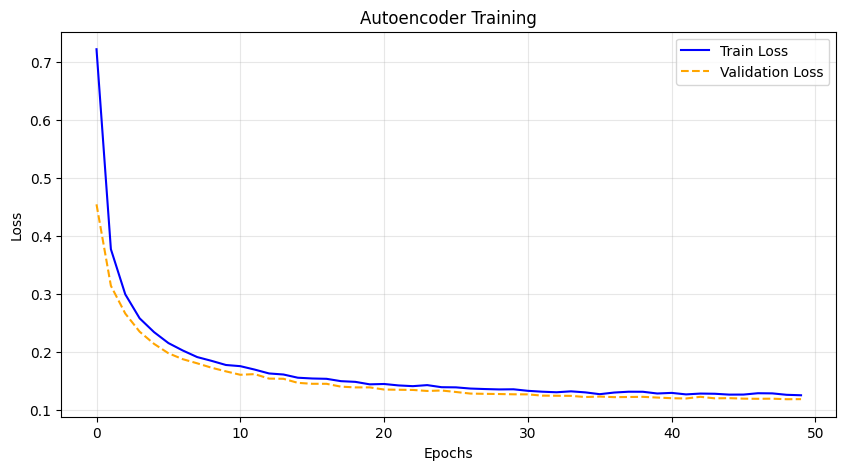

Pipeline complete. Train shape: (3502, 32), Test shape: (876, 32)
Saving models...
Error saving ../models/saits_model_centered.pth: cannot pickle '_thread.lock' object
Error saving ../models/ts2vec_model_centered.pth: cannot pickle '_thread.lock' object
Model saved: ../models/autoencoder_model_centered.pth


In [6]:
pipeline_centered = SepsisEncodingPipeline(
    file_path='../data/Dataset.csv',
    window_start=-6,
    window_end=5,
    min_presence_pct=1.0,
    validation_split=0.2,
    essential_cols=[
        'Hct', 'Platelets', 'Creatinine', 'Hgb', 'Temp',
        'O2Sat', 'Resp', 'BUN', 'Potassium', 'Glucose',
        'SBP', 'Calcium', 'Magnesium', 'HR', 'Phosphate',
        'Lactate', 'Bilirubin_total', 'WBC', 'MAP', 'DBP',
        'Hour', 'Patient_ID', 'will_have_sepsis'],
    saits_epochs=10,
    saits_batch_size=32,
    ts2vec_output_dims=32,
    ts2vec_epochs=30,
    ts2vec_batch_size=32,
    ae_latent_dim=32,
    ae_epochs=50,
    ae_batch_size=64,
    ae_lr=1e-3,
    device=device_dml,
    random_state=42
)
data_centered_out, models_centered_out = pipeline_centered.run()

saits_centered_trained, ts2vec_centered_trained, ae_centered_trained = models_centered_out

print("Saving models...")
SepsisEncodingPipeline.save_model(saits_centered_trained, "../models/saits_model_centered.pth")
SepsisEncodingPipeline.save_model(ts2vec_centered_trained, "../models/ts2vec_model_centered.pth")
SepsisEncodingPipeline.save_model(ae_centered_trained, "../models/autoencoder_model_centered.pth")

In [7]:
# Run this cell to persist encoded representations to disk
pipeline.save_processed_data(data_out, data_centered_out)

Data saved to: ../data\sepsis_processed_full.npz


## 3. Load Pre-Computed Representations

If the encoding pipeline has already been run and saved, load from disk directly.

In [8]:
pipeline = SepsisEncodingPipeline()
data_out, data_centered_out = pipeline.load_processed_data()

Data loaded.
Available arrays: ['X_train_encoded', 'X_test_encoded', 'y_train', 'y_test', 'X_train_pids', 'X_test_pids', 'X_centered_train_encoded', 'X_centered_test_encoded', 'y_centered_train', 'y_centered_test', 'X_centered_train_pids', 'X_centered_test_pids']


## 4. Patient Alignment

Build aligned dataframes pairing each sepsis patient's past and future embeddings.

In [9]:
X_train_encoded, X_test_encoded, y_train, y_test, X_train_pids, X_test_pids = data_out
X_centered_train_encoded, X_centered_test_encoded, y_centered_train, y_centered_test, X_centered_train_pids, X_centered_test_pids = data_centered_out

# Full past-window dataframe
df_pred = pd.DataFrame({
    'Patient_ID': X_train_pids,
    'will_have_sepsis': y_train,
    'emb': list(X_train_encoded)
})
def_pred = df_pred[df_pred['will_have_sepsis'] == 1].copy()

# Full future-window dataframe
df_pheno = pd.DataFrame({
    'Patient_ID': X_centered_train_pids,
    'will_have_sepsis': y_centered_train,
    'emb': list(X_centered_train_encoded)
})
def_pheno = df_pheno[df_pheno['will_have_sepsis'] == 1].copy()

# Align sepsis Patient on Patient_ID
merged_sepsis = pd.merge(
    def_pred[['Patient_ID', 'emb']],
    def_pheno[['Patient_ID', 'emb']],
    on='Patient_ID',
    suffixes=('_past', '_fut')
)

print(f"Full past dataset: {len(df_pred)} patients")
print(f"Aligned sepsis patient (past/future): {len(merged_sepsis)} patients")

Full past dataset: 2811 patients
Aligned sepsis patient (past/future): 1135 patients


## 5. Phenotype Clustering

Apply KMeans (k=4) on the future-window embeddings to define sepsis phenotype targets.
Past-window embeddings and cluster assignments are then used to train the gating network.

In [10]:
X_sepsis_fut = np.stack(merged_sepsis['emb_fut'].values)
X_sepsis_fut = normalize(X_sepsis_fut, axis=1)

kmeans_fut = KMeans(n_clusters=4, random_state=42, n_init=10)
merged_sepsis['cluster_target'] = kmeans_fut.fit_predict(X_sepsis_fut)

X_sepsis_past = np.stack(merged_sepsis['emb_past'].values)
X_sepsis_past = normalize(X_sepsis_past, axis=1)
y_sepsis_clusters = merged_sepsis['cluster_target'].values

X_g_train, X_g_val, y_g_train, y_g_val = train_test_split(
    X_sepsis_past,
    y_sepsis_clusters,
    test_size=0.20,
    random_state=42,
    stratify=y_sepsis_clusters
)

print(f"Gating network split: train={len(X_g_train)}, val={len(X_g_val)}")

Gating network split: train=908, val=227


## 6. Gating Network Training

Train the AttentionGatingNetwork to predict future phenotype clusters from past embeddings.
Evaluation is done on the validation split using AMI, silhouette score, and accuracy.

Training gating network (sepsis patients only)
Epoch 20/150 | Loss: 1.3144 | Val Acc: 0.4097
Epoch 40/150 | Loss: 1.2525 | Val Acc: 0.5242
Epoch 60/150 | Loss: 1.1842 | Val Acc: 0.5639
Epoch 80/150 | Loss: 1.1101 | Val Acc: 0.5859
Epoch 100/150 | Loss: 1.0416 | Val Acc: 0.6167
Epoch 120/150 | Loss: 0.9804 | Val Acc: 0.6079
Epoch 140/150 | Loss: 0.9307 | Val Acc: 0.6167


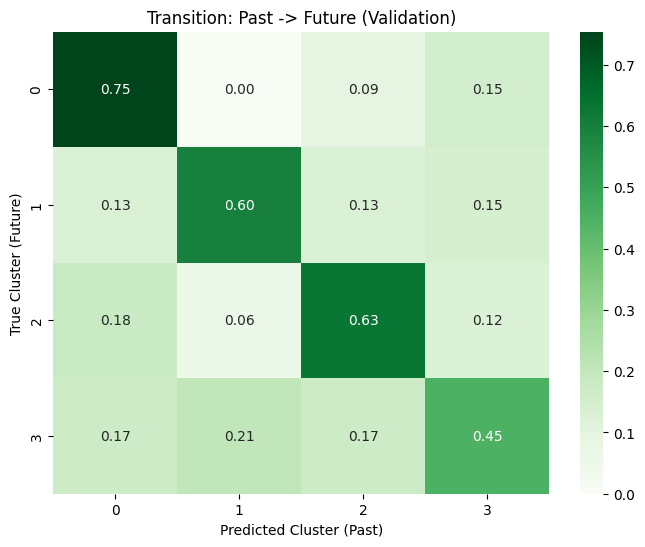

Performance Report
              precision    recall  f1-score   support

           0       0.65      0.75      0.70        65
           1       0.69      0.60      0.64        55
           2       0.57      0.63      0.60        49
           3       0.52      0.45      0.48        58

    accuracy                           0.61       227
   macro avg       0.61      0.61      0.61       227
weighted avg       0.61      0.61      0.61       227

Scores (Validation)
AMI (Adjusted Mutual Info): 0.2370
Silhouette (Latent Space):  0.1930
Accuracy (Recovery Rate):   0.6123


{'ami': 0.2369711225274342,
 'silhouette': 0.19297584891319275,
 'accuracy': 0.6123348017621145}

In [11]:
input_dim = X_g_train.shape[1]
gating_net = AttentionGatingNetwork(input_dim=input_dim, n_clusters=4)

print("Training gating network (sepsis patients only)")
history = gating_net.fit_model(X_g_train, y_g_train, X_g_val, y_g_val, epochs=150, lr=0.001)

logits_val, gate_val, query_val = gating_net.predict_detailed(X_g_val)

AttentionGatingNetwork.plot_transition_matrix(y_g_val, logits_val, title="Transition: Past -> Future (Validation)")
AttentionGatingNetwork.evaluate_performance(y_g_val, logits_val, query_val, stage_name="Validation")

## 7. Mixture of Experts

Train the MoE model on the full training population.
A grid search over MLP architectures and learning rates is used to select the best configuration,
evaluated by AUROC on the test set.
The final best model is then evaluated with the full diagnostic.

In [12]:
X_global_train = normalize(X_train_encoded, axis=1)
y_global_train = y_train
X_global_test = normalize(X_test_encoded, axis=1)
y_global_test = y_test

param_grid = {
    'hidden_layer_sizes': [
        (128, 64),
        (128, 64, 32),
        (256, 128),
        (256, 128, 32),
        (256, 128, 64)
    ],
    'learning_rate': [0.1, 0.05, 0.01, 0.005, 0.001]
}

keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

best_auroc = 0.0
best_params = None
best_model = None

print(f"Starting grid search ({len(combinations)} combinations)")

for i, params in enumerate(combinations):
    print(f"[{i+1}/{len(combinations)}] Config: {params}")

    moe_model = AttentionSepsisMoE(
        gating_net=gating_net,
        n_experts=4,
        hidden_layer_sizes=params['hidden_layer_sizes'],
        learning_rate=params['learning_rate']
    )
    moe_model.fit(X_global_train, y_global_train)

    y_prob = moe_model.predict_proba(X_global_test)
    current_auroc = roc_auc_score(y_global_test, y_prob)
    print(f"AUROC: {current_auroc:.4f}")

    if current_auroc > best_auroc:
        print("New best model.")
        best_auroc = current_auroc
        best_params = params
        best_model = moe_model

print(f"Grid search complete. Best AUROC: {best_auroc:.4f}")
print(f"Best config: {best_params}")

Starting grid search (25 combinations)
[1/25] Config: {'hidden_layer_sizes': (128, 64), 'learning_rate': 0.1}
Training 4 experts via attention gating
Expert 0: training on 858 patients.
Expert 1: training on 615 patients.
Expert 2: training on 738 patients.
Expert 3: training on 600 patients.
AUROC: 0.7588
New best model.
[2/25] Config: {'hidden_layer_sizes': (128, 64), 'learning_rate': 0.05}
Training 4 experts via attention gating
Expert 0: training on 858 patients.
Expert 1: training on 615 patients.
Expert 2: training on 738 patients.
Expert 3: training on 600 patients.
AUROC: 0.7659
New best model.
[3/25] Config: {'hidden_layer_sizes': (128, 64), 'learning_rate': 0.01}
Training 4 experts via attention gating
Expert 0: training on 858 patients.
Expert 1: training on 615 patients.
Expert 2: training on 738 patients.
Expert 3: training on 600 patients.
AUROC: 0.7707
New best model.
[4/25] Config: {'hidden_layer_sizes': (128, 64), 'learning_rate': 0.005}
Training 4 experts via attentio

Full Diagnostic: Attention-based MoE
Global Prediction Results
AUROC: 0.7723
AUPRC: 0.7380
Classification Report
              precision    recall  f1-score   support

  Non-Sepsis       0.73      0.71      0.72       366
      Sepsis       0.70      0.72      0.71       337

    accuracy                           0.71       703
   macro avg       0.71      0.71      0.71       703
weighted avg       0.71      0.71      0.71       703



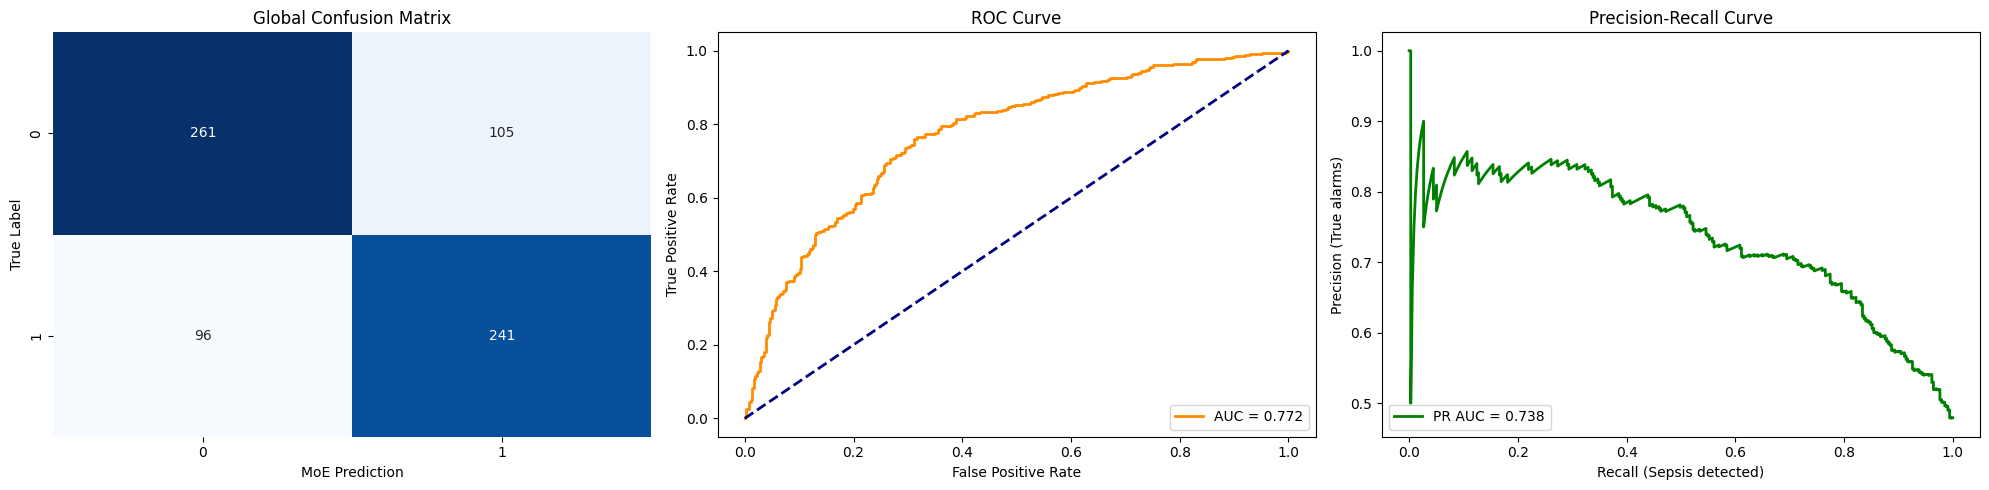

C:\Users\zaple\PycharmProjects\Research_Project_Sepsis\src\moe.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=assignments, ax=axes[0], palette="viridis")


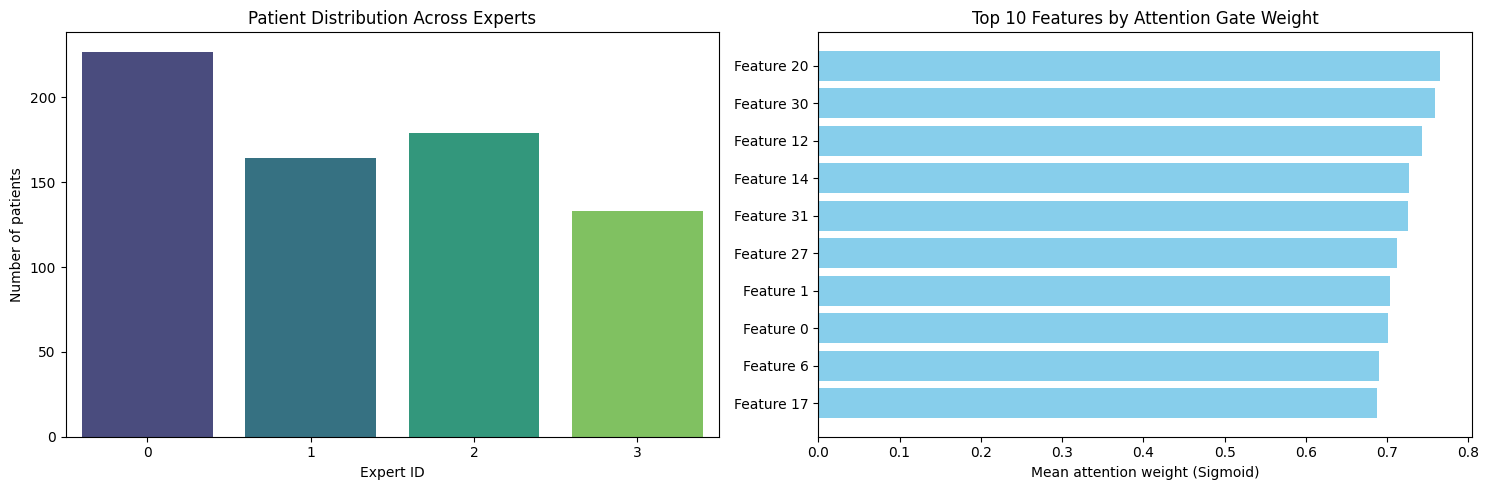

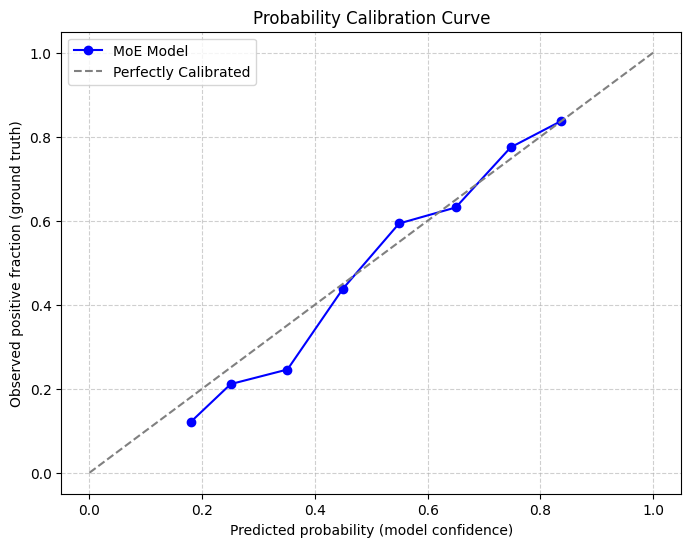

In [13]:
diagnostic = SepsisMoEDiagnostic(best_model, X_global_test, y_global_test)
diagnostic.run_full_diagnosis()